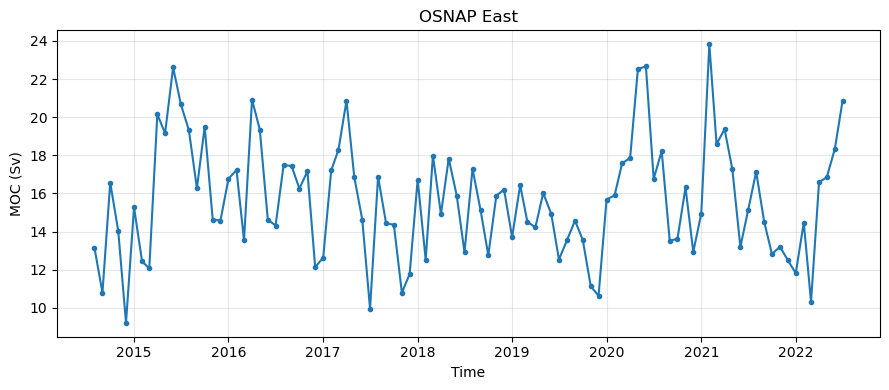

In [3]:
## Read and plot OSNAP-EAST 2014-2022
from datetime import datetime
import matplotlib.pyplot as plt

time = []
moc_sv = []

with open("osnap-east.txt", encoding="utf-8") as f:
    next(f)
    for line in f:
        month, value = line.split()
        time.append(datetime.strptime(month, "%Y-%m"))
        moc_sv.append(float(value))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time, moc_sv, marker="o", linewidth=1.5, markersize=3)
ax.set_xlabel("Time")
ax.set_ylabel("MOC (Sv)")
ax.set_title("OSNAP East")
ax.grid(True, alpha=0.3)
plt.tight_layout()

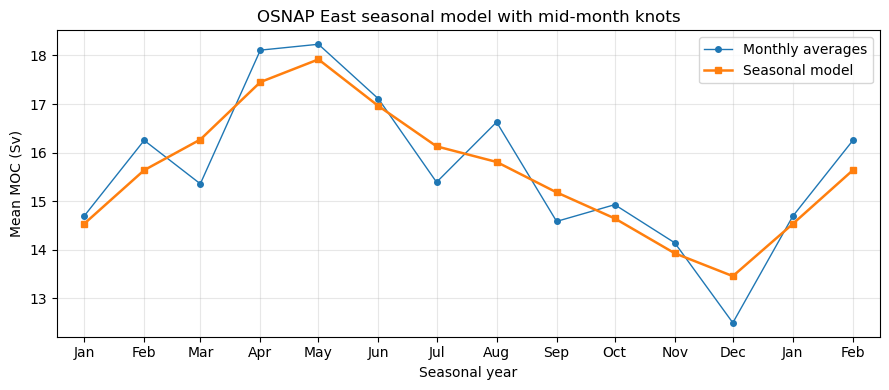

In [9]:
## Seasonal model with mid-month knots and weighted monthly smoothing
from datetime import datetime
import matplotlib.dates as mdates

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_mean = []
for month in range(1, 13):
    values = [value for date, value in zip(time, moc_sv) if date.month == month]
    monthly_mean.append(sum(values) / len(values))

model_mean = []
for i in range(12):
    previous_value = monthly_mean[(i - 1) % 12]
    current_value = monthly_mean[i]
    next_value = monthly_mean[(i + 1) % 12]
    model_mean.append((previous_value + 2 * current_value + next_value) / 4)

plot_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2]
plot_years = [2000] * 12 + [2001, 2001]
plot_time = [datetime(year, month, 15) for year, month in zip(plot_years, plot_months)]
plot_monthly_mean = [monthly_mean[month - 1] for month in plot_months]
plot_model_mean = [model_mean[month - 1] for month in plot_months]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(plot_time, plot_monthly_mean, marker="o", linewidth=1.0, markersize=4, label="Monthly averages")
ax.plot(plot_time, plot_model_mean, marker="s", linewidth=1.8, markersize=5, label="Seasonal model")

ax.set_xlim(datetime(2000, 1, 1), datetime(2001, 3, 1))
ax.set_xticks(plot_time)
ax.set_xticklabels([month_labels[month - 1] for month in plot_months])
ax.set_xlabel("Seasonal year")
ax.set_ylabel("Mean MOC (Sv)")
ax.set_title("OSNAP East seasonal model with mid-month knots")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

In [ ]:
## Seasonally corrected MOC values
overall_mean = sum(moc_sv) / len(moc_sv)

sv_corr = []
for date, value in zip(time, moc_sv):
    seasonal_value = model_mean[date.month - 1]
    sv_corr.append(value - seasonal_value + overall_mean)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time, moc_sv, marker="o", linewidth=1.0, markersize=3, alpha=0.55, label="Original")
ax.plot(time, sv_corr, marker="o", linewidth=1.5, markersize=3, label="Seasonally corrected")
ax.axhline(overall_mean, color="black", linewidth=1, linestyle="--", alpha=0.5, label="Overall mean")
ax.set_xlabel("Time")
ax.set_ylabel("MOC (Sv)")
ax.set_title("OSNAP East seasonally corrected MOC")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()